In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("EternalReturn_kakaogames_2024.csv")

In [3]:
df

,gameId,userNum,nickname,matchingTeamMode,characterNum,skinCode,characterLevel,gameRank,playerKill,playerAssistant,...,mmrGainInGame,mmrLossEntryCost,premadeMatchingType,viewContribution,useReconDrone,useEmpDrone,exceptPreMadeTeam,terminateCount,clutchCount,isLeavingBeforeCreditRevivalTerminate
0,35260427,4378745,쏘히,3,49,1049003,20,5,6,1,...,30,-44,1,21,3,0,False,0,0,False
1,35260427,4313007,쏘금,3,28,1028000,20,4,2,6,...,69,-44,1,27,6,0,False,1,0,False
2,35260427,4227659,어지럽네,3,23,1023002,20,2,2,8,...,128,-43,1,18,4,0,False,0,0,False
3,35260427,3979035,微笑的高圆圆,3,53,1053000,20,1,4,3,...,124,-43,1,31,6,0,False,1,0,False
4,35260427,2118488,minom1,3,65,1065001,20,1,2,4,...,124,-43,1,25,7,0,False,1,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204420,35765219,3927798,Toasty117,3,68,1068000,1,3,0,0,...,0,0,0,0,0,0,False,0,0,True
204421,35783095,4932642,1펀치쓰리강냉이,3,36,1036000,1,7,0,0,...,0,0,0,0,0,0,False,0,0,True
204422,35796912,456574,Luliet,3,74,1074000,1,8,0,0,...,0,0,0,0,0,0,False,0,0,True
204423,35804415,4519640,수원대장서예슬,3,8,1008000,1,8,0,0,...,0,-72,1,0,0,0,False,0,0,True


<Axes: >

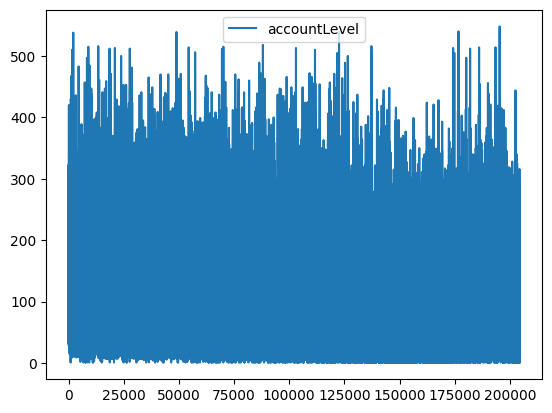

In [4]:
df[['accountLevel']].plot()

In [5]:
df['characterLevel'].sort_values(ascending=False)

0         20
18946     20
18957     20
18956     20
18955     20
          ..
204396     1
204397     1
204398     1
204399     1
204424     1
Name: characterLevel, Length: 204425, dtype: int64

In [6]:
df['battleZone1AreaCode'].value_counts()

battleZone1AreaCode
0      116940
190      5268
150      4999
100      4936
110      4933
60       4888
170      4754
90       4736
40       4686
130      4646
80       4627
20       4612
180      4596
160      4566
120      4541
30       4368
140      4287
50       4194
10       3958
70       3890
Name: count, dtype: int64

In [7]:
df['battleZone1Winner'].value_counts()

battleZone1Winner
0    146369
1     58056
Name: count, dtype: int64

In [ ]:
# 실력별 세그먼트 분류 위해 0점, 1~2000점, 
# 2001~4000점, 4001~6000점, 6001+로 5개의 세그먼트로 분류
# (이상치/결측치 없음, 분류 기준은 추후 변경 가능)
bins = [-1, 2400, 3600, 6400,np.inf]
labels = ['아이언&브론즈', '실버&골드', '플래티넘&다이아', '메테오라이트+']

df['rank_group'] = pd.cut(
    df['rankPoint'],
    bins=bins,
    labels=labels
    )

df['rank_group']

df['rank_type'] = np.where(
    (df['mmrGainInGame'] == 0) & (df['mmrLossEntryCost'] == 0),
    'rank_none','rank_game')

# 1. 우선 게임 단위로 
# mmr 수치 중에 하나라도 mmr이 0이 아니라면
game_rank_flag = (
    df
    .groupby("gameId")
    .apply(
        lambda x: (
            (x["mmrGainInGame"] != 0).any() or
            (x["mmrLossEntryCost"] != 0).any()
        )
    )
    .reset_index(name="is_rank_game")
)

# 통째로 df1에 merge
df1 = df.merge(game_rank_flag, on="gameId", how="left")

# 랭크게임 여부를 확인하는 rank_type_v2 컬럼 추가
df1["rank_type_v2"] = df1["is_rank_game"].map(
    {True: "rank_game", False: "rank_none"}
)

df1["rank_type_v2"].value_counts()


In [9]:
df['rank_group']

0         4001~6000
1         4001~6000
2         4001~6000
3         4001~6000
4         4001~6000
            ...    
204420            0
204421            0
204422            0
204423    4001~6000
204424            0
Name: rank_group, Length: 204425, dtype: category
Categories (5, object): ['0' < '1~2000' < '2001~4000' < '4001~6000' < '6001+']

In [10]:
df.isnull().sum()[lambda x : x > 0]

nickname                 3
language                37
killer                7601
killDetail            7608
causeOfDeath         21268
placeOfDeath          7602
killerCharacter       8863
killerWeapon          9718
killer2              64909
killDetail2          64909
causeOfDeath2        76383
placeOfDeath2        64906
killerCharacter2     66102
killerWeapon2        66685
killer3             123667
killDetail3         123667
causeOfDeath3       130934
placeOfDeath3       123667
killerCharacter3    124405
killerWeapon3       124718
dtype: int64

In [11]:
df['language']

0                     Korean
1                     Korean
2                     Korean
3          ChineseSimplified
4                     Korean
                 ...        
204420               English
204421                Korean
204422    ChineseTraditional
204423                Korean
204424               Russian
Name: language, Length: 204425, dtype: object

In [12]:
# 닉네임 결측치 확인
df[df['nickname'].isna()]

# 닉네임 별 대체 위해 userNum=1369612 중 nickname을 갖는 것이 있는지 확인 : 전체 Null이다.
df[df['userNum'] == 1369612]

# 참조하여 대체가 아닌 특정 값으로 대체하여 사용
df['nickname'] = df['nickname'].fillna('user1369612')

In [13]:
df['nickname'].isnull().sum()

0

In [14]:
df['killDetail']

0              너구리사냥
1               어지럽네
2             ちょうちょう
3              ooooo
4              밝은보름달
             ...    
204420        Uptown
204421     Warehouse
204422    GasStation
204423        School
204424        School
Name: killDetail, Length: 204425, dtype: object

In [15]:
df['killerUserNum']

0         1549251
1         4227659
2          988185
3          108836
4          666326
           ...   
204420          0
204421          0
204422          0
204423          0
204424          0
Name: killerUserNum, Length: 204425, dtype: int64

In [16]:
df['killer']

0                 player
1                 player
2                 player
3                 player
4                 player
               ...      
204420    restrictedArea
204421    restrictedArea
204422    restrictedArea
204423    restrictedArea
204424    restrictedArea
Name: killer, Length: 204425, dtype: object

In [17]:
df['causeOfDeath']

0                        쇼이치 기본공격
1                         이머전시 OP
2                           몽환 나비
3                             NaN
4                     basicAttack
                   ...           
204420    restrictedAreaExplosion
204421    restrictedAreaExplosion
204422    restrictedAreaExplosion
204423    restrictedAreaExplosion
204424    restrictedAreaExplosion
Name: causeOfDeath, Length: 204425, dtype: object

In [18]:
df['placeOfDeath']

0         180.0
1         110.0
2          50.0
3         170.0
4          50.0
          ...  
204420     60.0
204421     20.0
204422     80.0
204423    190.0
204424    190.0
Name: placeOfDeath, Length: 204425, dtype: float64

In [19]:
df['killerCharacter']

0         Shoichi
1           Cathy
2           Vanya
3            Yuki
4          Echion
           ...   
204420        NaN
204421        NaN
204422        NaN
204423        NaN
204424        NaN
Name: killerCharacter, Length: 204425, dtype: object

In [20]:
df['killerWeapon']

0         OneHandSword
1         OneHandSword
2               Arcana
3         TwoHandSword
4                VFArm
              ...     
204420             NaN
204421             NaN
204422             NaN
204423             NaN
204424             NaN
Name: killerWeapon, Length: 204425, dtype: object

In [21]:
df['versionMajor'].value_counts()

versionMajor
23    117551
22     86874
Name: count, dtype: int64

In [22]:
df['versionMinor'].value_counts()

versionMinor
0    117551
1     86874
Name: count, dtype: int64

In [ ]:
df['startDtm'].sort_values()

0         2024-05-30T15:36:52.052+0900
1         2024-05-30T15:36:52.052+0900
2         2024-05-30T15:36:52.052+0900
3         2024-05-30T15:36:52.052+0900
4         2024-05-30T15:36:52.052+0900
                      ...             
204420    2024-06-11T00:59:56.056+0900
204421    2024-06-11T17:51:31.031+0900
204422    2024-06-11T23:05:07.007+0900
204423    2024-06-12T01:32:29.029+0900
204424    2024-06-12T21:15:23.023+0900
Name: startDtm, Length: 204425, dtype: object

In [24]:
# bool, 1=victory
df['victory']

0         0
1         0
2         0
3         1
4         1
         ..
204420    0
204421    0
204422    0
204423    0
204424    0
Name: victory, Length: 204425, dtype: int64

In [25]:
df['characterNum'].value_counts().sort_index(ascending=True)

characterNum
1     3781
2     7309
3     1594
4     4631
5      789
      ... 
70    3144
71    4339
72    7112
73    2878
74    7422
Name: count, Length: 74, dtype: int64

In [26]:
df['tacticalSkillGroup'].value_counts().sort_index()

tacticalSkillGroup
30        83306
40         6537
50         6456
60        21451
70        18307
80        17685
90          136
110        3360
120        7122
130       17180
140        6145
150        5052
500120     6139
500130     1060
500140      355
500150     1101
500190      913
500200     1024
500220     1096
Name: count, dtype: int64

In [27]:
## skillLevelinfo -> 언어데이터로 맵핑
## df['skillLevelinfo_named']

import ast
from pathlib import Path

def load_l10n_from_file(path: str, encoding="utf-8-sig") -> dict[str, str]:
    text = Path(path).read_text(encoding=encoding)
    l10n = {}
    for line in text.splitlines():
        if "┃" not in line:
            continue
        k, v = line.split("┃", 1)
        l10n[k] = v
    return l10n

def extract_skill_group_names(l10n: dict) -> dict[int, str]:
    prefix = "Skill/Group/Name/"
    out = {}
    for k, v in l10n.items():
        if k.startswith(prefix):
            suffix = k[len(prefix):]
            if suffix.isdigit():
                out[int(suffix)] = v
    return out

df = pd.read_csv("EternalReturn_kakaogames_2024.csv")  

l10n = load_l10n_from_file("l10n-Korean-20260108051557.txt")
skill_name_map = extract_skill_group_names(l10n)

def parse_skilllevelinfo_cell(x):
    if pd.isna(x) or x == "" or x == "{}":
        return {}
    if isinstance(x, dict):
        d = x
    else:
        d = ast.literal_eval(x)
    return {int(k): int(v) for k, v in d.items()}

def map_skill_codes_to_names(skill_dict: dict[int, int], name_map: dict[int, str]):
    return {name_map.get(code, f"UNKNOWN_{code}"): lvl for code, lvl in skill_dict.items()}

df["skillLevelInfo_named"] = (
    df["skillLevelInfo"]
      .apply(parse_skilllevelinfo_cell)
      .apply(lambda d: map_skill_codes_to_names(d, skill_name_map))
)


In [28]:
df['skillLevelInfo_named']

0         {'선풍참': 5, '반월참': 1, '질풍뇌격': 3, '연계 창술': 2, '뇌...
1         {'돈키호테': 5, '오딧세이': 5, '파랑새': 5, '마음의 양식': 2, ...
2         {'망토와 단검': 3, '쌍검 난무': 3, '동맥절제술': 5, '엠퓨테이션':...
3         {'전사의 돌격': 5, '전투 교범': 5, '파괴': 5, '지각변동': 3, ...
4         {'크레센트 댄스': 4, '크레센트 슬래시': 3, '휠 댄스': 1, '블루&레...
                                ...                        
204420                                                   {}
204421                                                   {}
204422                                            {'추심': 1}
204423                                                   {}
204424                                          {'선빵필승': 1}
Name: skillLevelInfo_named, Length: 204425, dtype: object

In [29]:
df

,gameId,userNum,nickname,matchingTeamMode,characterNum,skinCode,characterLevel,gameRank,playerKill,playerAssistant,...,mmrLossEntryCost,premadeMatchingType,viewContribution,useReconDrone,useEmpDrone,exceptPreMadeTeam,terminateCount,clutchCount,isLeavingBeforeCreditRevivalTerminate,skillLevelInfo_named
0,35260427,4378745,쏘히,3,49,1049003,20,5,6,1,...,-44,1,21,3,0,False,0,0,False,"{'선풍참': 5, '반월참': 1, '질풍뇌격': 3, '연계 창술': 2, '뇌..."
1,35260427,4313007,쏘금,3,28,1028000,20,4,2,6,...,-44,1,27,6,0,False,1,0,False,"{'돈키호테': 5, '오딧세이': 5, '파랑새': 5, '마음의 양식': 2, ..."
2,35260427,4227659,어지럽네,3,23,1023002,20,2,2,8,...,-43,1,18,4,0,False,0,0,False,"{'망토와 단검': 3, '쌍검 난무': 3, '동맥절제술': 5, '엠퓨테이션':..."
3,35260427,3979035,微笑的高圆圆,3,53,1053000,20,1,4,3,...,-43,1,31,6,0,False,1,0,False,"{'전사의 돌격': 5, '전투 교범': 5, '파괴': 5, '지각변동': 3, ..."
4,35260427,2118488,minom1,3,65,1065001,20,1,2,4,...,-43,1,25,7,0,False,1,0,False,"{'크레센트 댄스': 4, '크레센트 슬래시': 3, '휠 댄스': 1, '블루&레..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204420,35765219,3927798,Toasty117,3,68,1068000,1,3,0,0,...,0,0,0,0,0,False,0,0,True,{}
204421,35783095,4932642,1펀치쓰리강냉이,3,36,1036000,1,7,0,0,...,0,0,0,0,0,False,0,0,True,{}
204422,35796912,456574,Luliet,3,74,1074000,1,8,0,0,...,0,0,0,0,0,False,0,0,True,{'추심': 1}
204423,35804415,4519640,수원대장서예슬,3,8,1008000,1,8,0,0,...,-72,1,0,0,0,False,0,0,True,{}


In [30]:
#기존 컬럼 개수
len(df.columns)

229

In [31]:
# import json

# with open("character_stat.json", "r", encoding="utf-8") as f:
#     j = json.load(f)

# char_map = {row["code"]: row["name"] for row in j["data"]}

# df["characterNum"] = pd.to_numeric(df["characterNum"], errors="coerce").astype("Int64")
# df["characterName_en"] = df["characterNum"].map(char_map)


In [32]:
# df['characterNum'].sort_values()

In [33]:
import json

with open("character_stat.json", "r", encoding="utf-8") as f:
    j = json.load(f)

df_char = pd.DataFrame(j["data"])                 # code, name, maxHp, attackPower, ...
df_char = df_char.rename(columns={"code": "characterNum", "name": "characterName_en"})

df["characterNum"] = pd.to_numeric(df["characterNum"], errors="coerce").astype("Int64")
df_char["characterNum"] = pd.to_numeric(df_char["characterNum"], errors="coerce").astype("Int64")

df = df.merge(df_char, on="characterNum", how="left")


In [34]:
df

,gameId,userNum,nickname,matchingTeamMode,characterNum,skinCode,characterLevel,gameRank,playerKill,playerAssistant,...,localScaleInVictoryScene,resource,lobbySubObject,charArcheType1,charArcheType2,weaponRangeType,comboTime,forcedComboAttack,isUIPlayerStatusBarStaminaFilled,isUIPlayerStatusBarVitalityFilled
0,35260427,4378745,쏘히,3,49,1049003,20,5,6,1,...,M,Felix,,Warrior,None,Melee,0,True,False,False
1,35260427,4313007,쏘금,3,28,1028000,20,4,2,6,...,S,Sua,,Warrior,Mage,Melee,0,True,False,False
2,35260427,4227659,어지럽네,3,23,1023002,20,2,2,8,...,S,Cathy,,Assasin,None,Melee,1,True,False,False
3,35260427,3979035,微笑的高圆圆,3,53,1053000,20,1,4,3,...,L,Markus,,Tanker,Warrior,Melee,0,True,False,False
4,35260427,2118488,minom1,3,65,1065001,20,1,2,4,...,S,DebiMarlene,,Warrior,None,Melee,0,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204420,35765219,3927798,Toasty117,3,68,1068000,1,3,0,0,...,M,Alonso,,Tanker,None,Melee,0,True,False,False
204421,35783095,4932642,1펀치쓰리강냉이,3,36,1036000,1,7,0,0,...,S,Eva,,Mage,None,Range,0,True,False,False
204422,35796912,456574,Luliet,3,74,1074000,1,8,0,0,...,L,Darko,,Warrior,None,Melee,0,True,False,False
204423,35804415,4519640,수원대장서예슬,3,8,1008000,1,8,0,0,...,S,Hart,,Marksman,None,Range,0,True,False,False


In [35]:
#스탯 컬럼 붙인 이후
len(df.columns)

270

In [36]:
# name
# maxHp
# maxSp
# maxVp
# strLearnStartSkill
# strUsePointLearnStartSkill
# maxExtraPoint
# attackPower
# defense
# skillAmp
# adaptiveForce
# criticalStrikeChance

# spRegen
# vpRegen
# attackSpeed
# attackSpeedRatio
# increaseBasicAttackDamageRatio
# skillAmpRatio
# preventBasicAttackDamagedRatio
# preventSkillDamagedRatio
   
# attackSpeedLimit
# attackSpeedMin
# moveSpeed
# sightRange
# radius
# pathingRadius
# uiHeight
# initStateDisplayIndex
     
# localScaleInCutscene
      
# localScaleInVictoryScene
 

# lobbySubObject
# charArcheType1
     
# charArcheType2
# weaponRangeType
# forcedComboAttack
# isUIPlayerStatusBarStaminaFilled
# isUIPlayerStatusBarVitalityFilled

In [37]:
# maxHp
# attack
# Power
# defense
# attackSpeed

In [38]:
df.columns[-42:]

Index(['skillLevelInfo_named', 'characterName_en', 'maxHp_y', 'maxSp_y',
       'maxVp', 'strLearnStartSkill', 'strUsePointLearnStartSkill',
       'initExtraPoint', 'maxExtraPoint', 'attackPower_y', 'defense_y',
       'skillAmp_y', 'adaptiveForce_y', 'criticalStrikeChance_y', 'hpRegen_y',
       'spRegen_y', 'vpRegen', 'attackSpeed_y', 'attackSpeedRatio',
       'increaseBasicAttackDamageRatio', 'skillAmpRatio',
       'preventBasicAttackDamagedRatio', 'preventSkillDamagedRatio',
       'attackSpeedLimit', 'attackSpeedMin', 'moveSpeed_y', 'sightRange_y',
       'radius', 'pathingRadius', 'uiHeight', 'initStateDisplayIndex',
       'localScaleInCutscene', 'localScaleInVictoryScene', 'resource',
       'lobbySubObject', 'charArcheType1', 'charArcheType2', 'weaponRangeType',
       'comboTime', 'forcedComboAttack', 'isUIPlayerStatusBarStaminaFilled',
       'isUIPlayerStatusBarVitalityFilled'],
      dtype='object')

In [39]:
df.iloc[:, -42:].head()

,skillLevelInfo_named,characterName_en,maxHp_y,maxSp_y,maxVp,strLearnStartSkill,strUsePointLearnStartSkill,initExtraPoint,maxExtraPoint,attackPower_y,...,localScaleInVictoryScene,resource,lobbySubObject,charArcheType1,charArcheType2,weaponRangeType,comboTime,forcedComboAttack,isUIPlayerStatusBarStaminaFilled,isUIPlayerStatusBarVitalityFilled
0,"{'선풍참': 5, '반월참': 1, '질풍뇌격': 3, '연계 창술': 2, '뇌...",Felix,960,0,0,"Passive,Attack,SpecialSkill",,0,2,35,...,M,Felix,,Warrior,None,Melee,0,True,False,False
1,"{'돈키호테': 5, '오딧세이': 5, '파랑새': 5, '마음의 양식': 2, ...",Sua,1070,0,0,"Passive,Attack,SpecialSkill",,0,0,39,...,S,Sua,,Warrior,Mage,Melee,0,True,False,False
2,"{'망토와 단검': 3, '쌍검 난무': 3, '동맥절제술': 5, '엠퓨테이션':...",Cathy,940,0,0,"Passive,Attack,SpecialSkill",,0,0,29,...,S,Cathy,,Assasin,None,Melee,1,True,False,False
3,"{'전사의 돌격': 5, '전투 교범': 5, '파괴': 5, '지각변동': 3, ...",Markus,920,0,0,"Passive,Attack,SpecialSkill",,0,0,34,...,L,Markus,,Tanker,Warrior,Melee,0,True,False,False
4,"{'크레센트 댄스': 4, '크레센트 슬래시': 3, '휠 댄스': 1, '블루&레...",DebiMarlene,970,0,0,"Passive,Attack,SpecialSkill",Active3,0,0,33,...,S,DebiMarlene,,Warrior,None,Melee,0,True,False,False


In [40]:
df['maxHp_y']

0          960
1         1070
2          940
3          920
4          970
          ... 
204420    1000
204421     940
204422     960
204423     880
204424    1000
Name: maxHp_y, Length: 204425, dtype: int64

In [ ]:
## 태블로 활용을 위한 csv파일 저장

# df.to_csv("processed.csv", index=False)

In [47]:
df['bestWeapon'].value_counts()

bestWeapon
14    17802
24    17110
3     16316
1     14171
16    13738
11    12420
10    11841
21    10828
9     10408
5     10298
6      9322
7      8799
13     8229
15     8073
4      6877
2      6780
18     6025
19     4335
22     3118
20     2809
8      2101
25     1653
23     1372
Name: count, dtype: int64

In [48]:
df['totalVFCredits']

0         [0, 73, 67, 58, 64, 62, 73, 68, 80, 76, 162, 4...
1         [0, 73, 50, 60, 56, 56, 74, 53, 59, 73, 42, 53...
2         [0, 73, 48, 62, 58, 43, 50, 53, 72, 48, 52, 77...
3         [0, 68, 68, 68, 56, 40, 50, 56, 67, 74, 38, 46...
4         [0, 68, 63, 69, 58, 40, 49, 51, 37, 68, 38, 56...
                                ...                        
204420    [0, 0, 66, 40, 55, 41, 48, 47, 48, 40, 39, 38,...
204421    [53, 42, 21, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
204422    [0, 54, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...
204423    [42, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...
204424    [0, 0, 47, 11, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...
Name: totalVFCredits, Length: 204425, dtype: object

In [51]:
df['startDtm'].sort_values()

61041     2024-05-30T15:33:02.002+0900
163878    2024-05-30T15:33:02.002+0900
163879    2024-05-30T15:33:02.002+0900
170624    2024-05-30T15:33:02.002+0900
61042     2024-05-30T15:33:02.002+0900
                      ...             
143021    2024-06-12T23:09:46.046+0900
128222    2024-06-12T23:09:46.046+0900
128221    2024-06-12T23:09:46.046+0900
28418     2024-06-12T23:09:46.046+0900
110753    2024-06-12T23:09:46.046+0900
Name: startDtm, Length: 204425, dtype: object

In [ ]:
df['bestWeapon']